# Monte-Carlo simulation in X-ray data analysis

Contact: Honghui Liu (honghui.liu\<at\>uni-tuebingen.de)

In [1]:
import numpy as np
import emcee
import matplotlib.pyplot as plt
from astropy.io import fits

import matplotlib_inline
#set_matplotlib_formats('svg')
matplotlib_inline.backend_inline.set_matplotlib_formats("svg")

## Case I: Stokes parameters and uncertainties for X-ray linear polarization
(generated by ChatGPT)

In an event-based X-ray polarization analysis, each photon has a reconstructed photoelectron emission angle $\phi_i$. In this note, we use the convention **with the extra factor of 2** in the event-level Stokes parameters:

$$
i_i = 1,
$$

$$
q_i = 2\cos(2\phi_i),
$$

$$
u_i = 2\sin(2\phi_i).
$$

If event weights $w_i$ are used, the binned Stokes parameters are

$$
I = \sum_i w_i,
$$

$$
Q = \sum_i 2w_i\cos(2\phi_i),
$$

$$
U = \sum_i 2w_i\sin(2\phi_i).
$$

For unweighted events, $w_i=1$, so

$$
I=N,
$$

$$
Q = \sum_i 2\cos(2\phi_i),
$$

$$
U = \sum_i 2\sin(2\phi_i).
$$

The normalized Stokes parameters are

$$
q = \frac{Q}{I},
$$

$$
u = \frac{U}{I}.
$$

With this factor-2 convention, the measured modulation amplitude is

$$
a = \sqrt{q^2+u^2}.
$$

For a detector with modulation factor $\mu$, the polarization degree is

$$
PD = \frac{1}{\mu}\sqrt{q^2+u^2},
$$

where $\mu$ is the modulation factor. If $Q$ and $U$ have already been corrected for the modulation factor, then one can simply use

$$
PD = \sqrt{q^2+u^2}.
$$

The polarization angle is

$$
PA = \frac{1}{2}\operatorname{atan2}(u,q).
$$

The factor $1/2$ appears because linear polarization has a $180^\circ$ symmetry.

---

### Uncertainties on $I,Q,U$

For weighted events, the variances can be estimated as

$$
\sigma_I^2 = \sum_i w_i^2,
$$

$$
\sigma_Q^2 = \sum_i w_i^2 \left[2\cos(2\phi_i)\right]^2,
$$

$$
\sigma_U^2 = \sum_i w_i^2 \left[2\sin(2\phi_i)\right]^2.
$$

The covariances are

$$
{\rm Cov}(I,Q) = \sum_i 2w_i^2\cos(2\phi_i),
$$

$$
{\rm Cov}(I,U) = \sum_i 2w_i^2\sin(2\phi_i),
$$

$$
{\rm Cov}(Q,U) = \sum_i w_i^2 \left[2\cos(2\phi_i)\right]\left[2\sin(2\phi_i)\right].
$$

For unweighted events and weak polarization, the approximate results are

$$
\sigma_I^2 \simeq N,
$$

$$
\sigma_Q^2 \simeq 2N,
$$

$$
\sigma_U^2 \simeq 2N,
$$

and

$$
{\rm Cov}(I,Q) \simeq 0,
$$

$$
{\rm Cov}(I,U) \simeq 0,
$$

$$
{\rm Cov}(Q,U) \simeq 0.
$$

Therefore,

$$
\sigma_I \simeq \sqrt{N},
$$

$$
\sigma_Q \simeq \sqrt{2N},
$$

$$
\sigma_U \simeq \sqrt{2N}.
$$

---

### Uncertainties on normalized Stokes parameters $q$ and $u$

The normalized Stokes parameters are

$$
q = \frac{Q}{I},
$$

$$
u = \frac{U}{I}.
$$

Using error propagation, the variance of $q$ is

$$
\sigma_q^2 = \frac{\sigma_Q^2}{I^2} + \frac{Q^2\sigma_I^2}{I^4} - \frac{2Q}{I^3}{\rm Cov}(I,Q).
$$

Equivalently, since $q=Q/I$,

$$
\sigma_q^2 = \frac{1}{I^2}\left[\sigma_Q^2 + q^2\sigma_I^2 - 2q{\rm Cov}(I,Q)\right].
$$

Similarly,

$$
\sigma_u^2 = \frac{1}{I^2}\left[\sigma_U^2 + u^2\sigma_I^2 - 2u{\rm Cov}(I,U)\right].
$$

The covariance between $q$ and $u$ is

$$
{\rm Cov}(q,u) = \frac{1}{I^2}\left[{\rm Cov}(Q,U) - u{\rm Cov}(I,Q) - q{\rm Cov}(I,U) + qu\sigma_I^2\right].
$$

If the covariances between $I,Q,U$ are negligible, then

$$
\sigma_q^2 \simeq \frac{\sigma_Q^2}{I^2} + \frac{q^2\sigma_I^2}{I^2},
$$

$$
\sigma_u^2 \simeq \frac{\sigma_U^2}{I^2} + \frac{u^2\sigma_I^2}{I^2},
$$

$$
{\rm Cov}(q,u) \simeq \frac{qu\sigma_I^2}{I^2}.
$$

If $q\ll1$, $u\ll1$, and the source is weakly polarized, the terms involving $q^2$, $u^2$, and $qu$ are small. Then

$$
\sigma_q \simeq \frac{\sigma_Q}{I},
$$

$$
\sigma_u \simeq \frac{\sigma_U}{I}.
$$

For unweighted events with $I=N$, using the factor-2 convention,

$$
\sigma_q \simeq \sqrt{\frac{2}{N}},
$$

$$
\sigma_u \simeq \sqrt{\frac{2}{N}}.
$$

---

### Exact error propagation from $q,u$ to $PD,PA$

Define

$$
r = \sqrt{q^2+u^2}.
$$

With the factor-2 convention,

$$
PD = \frac{1}{\mu}r.
$$

For compactness, define

$$
k = \frac{1}{\mu}.
$$

Then

$$
PD = k\sqrt{q^2+u^2}.
$$

If the modulation correction has already been applied, use $k=1$.

The derivatives of $PD$ are

$$
\frac{\partial PD}{\partial q} = k\frac{q}{\sqrt{q^2+u^2}},
$$

$$
\frac{\partial PD}{\partial u} = k\frac{u}{\sqrt{q^2+u^2}}.
$$

Therefore, the propagated uncertainty on $PD$ is

$$
\sigma_{PD}^2 = k^2 \frac{q^2\sigma_q^2 + u^2\sigma_u^2 + 2qu{\rm Cov}(q,u)}{q^2+u^2}.
$$

The polarization angle is

$$
PA = \frac{1}{2}\operatorname{atan2}(u,q).
$$

The derivatives are

$$
\frac{\partial PA}{\partial q} = -\frac{1}{2}\frac{u}{q^2+u^2},
$$

$$
\frac{\partial PA}{\partial u} = \frac{1}{2}\frac{q}{q^2+u^2}.
$$

Therefore, the propagated uncertainty on $PA$ is

$$
\sigma_{PA}^2 = \frac{1}{4(q^2+u^2)^2}\left[u^2\sigma_q^2 + q^2\sigma_u^2 - 2qu{\rm Cov}(q,u)\right].
$$

This gives $\sigma_{PA}$ in radians. To convert to degrees,

$$
\sigma_{PA,{\rm deg}} = \sigma_{PA,{\rm rad}}\frac{180^\circ}{\pi}.
$$

---

### High-significance approximation

At high significance, the posterior in the $q-u$ plane is approximately Gaussian and far from the origin. If

$$
\sigma_q = \sigma_u = \sigma,
$$

and

$$
{\rm Cov}(q,u)=0,
$$

then the uncertainty on

$$
r = \sqrt{q^2+u^2}
$$

is approximately

$$
\sigma_r \simeq \sigma.
$$

Since

$$
PD = kr,
$$

the uncertainty on $PD$ is

$$
\sigma_{PD} \simeq k\sigma.
$$

For the factor-2 convention,

$$
k = \frac{1}{\mu},
$$

so

$$
\sigma_{PD} \simeq \frac{1}{\mu}\sigma.
$$

If the data products are already corrected so that $PD=\sqrt{q^2+u^2}$, then $k=1$, and

$$
\sigma_{PD} \simeq \sigma.
$$

For the polarization angle, the high-significance approximation gives

$$
\sigma_{PA} \simeq \frac{1}{2}\frac{\sigma}{\sqrt{q^2+u^2}}.
$$

Since

$$
PD = k\sqrt{q^2+u^2},
$$

this can also be written as

$$
\sigma_{PA} \simeq \frac{1}{2}\frac{\sigma_{PD}}{PD}.
$$

This expression is in radians. In degrees,

$$
\sigma_{PA,{\rm deg}} \simeq \frac{1}{2}\frac{\sigma_{PD}}{PD}\frac{180^\circ}{\pi}.
$$

Numerically,

$$
\sigma_{PA,{\rm deg}} \simeq 28.65^\circ\left(\frac{\sigma_{PD}}{PD}\right).
$$

Thus, for example, if

$$
PD = 4%,
$$

and

$$
\sigma_{PD} = 1%,
$$

then

$$
\sigma_{PA} \simeq 28.65^\circ\frac{1}{4} \simeq 7.2^\circ.
$$

---

### Important caveat at low significance

The high-significance approximation is valid only when the measured polarization is well separated from the origin in the $q-u$ plane. When

$$
\frac{PD}{\sigma_{PD}} \lesssim 2,
$$

the distribution of $PD$ becomes non-Gaussian and biased upward because

$$
PD \geq 0.
$$

The polarization angle may also become poorly constrained because $PA$ is undefined at

$$
q=u=0.
$$

Therefore, at low significance, it is better to perform statistical inference in the $q-u$ plane, or equivalently in the $I,Q,U$ space, and then transform the posterior samples to $PD$ and $PA$.


In [2]:
# ============================================================
# Basic polarization relations
# ============================================================

def qu_from_pdpa(pd, pa_deg):
    """
    Convert polarization degree and angle to normalized Stokes q,u.

    PA is in degrees.
    q = PD cos(2 PA)
    u = PD sin(2 PA)
    """
    pa = np.deg2rad(pa_deg)
    q = pd * np.cos(2.0 * pa)
    u = pd * np.sin(2.0 * pa)
    return q, u


def pdpa_from_qu(q, u):
    """
    Convert normalized Stokes q,u to polarization degree and angle.

    PD = sqrt(q^2 + u^2)
    PA = 0.5 atan2(u, q)

    PA is returned in degrees in the range [-90, 90).
    """
    pd = np.sqrt(q**2 + u**2)
    pa = 0.5 * np.rad2deg(np.arctan2(u, q))

    # Optional: keep PA in [-90, 90)
    pa = ((pa + 90.0) % 180.0) - 90.0

    return pd, pa


# ============================================================
# Gaussian likelihood in q,u
# ============================================================

def log_likelihood_qu(theta, q_obs, u_obs, cov):
    """
    Gaussian likelihood in the measured q,u plane.

    theta = [q, u]
    """
    q, u = theta
    diff = np.array([q - q_obs, u - u_obs])
    inv_cov = np.linalg.inv(cov)
    return -0.5 * diff @ inv_cov @ diff


def log_prior_qu(theta):
    """
    Simple broad physical prior.

    We require PD <= 1.
    For most X-ray polarization measurements this boundary is irrelevant.
    """
    q, u = theta
    pd = np.sqrt(q**2 + u**2)

    if pd <= 1.0:
        return 0.0
    else:
        return -np.inf


def log_posterior_qu(theta, q_obs, u_obs, cov):
    lp = log_prior_qu(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_qu(theta, q_obs, u_obs, cov)

In [3]:
def run_emcee_mcmc(
    q_obs,
    u_obs,
    cov,
    n_walkers=32,
    n_steps=10000,
    burn=2000,
    seed=1,
):
    """
    Run an emcee ensemble MCMC chain in q,u.

    Parameters
    ----------
    q_obs, u_obs : float
        Observed normalized Stokes parameters.

    cov : 2x2 array
        Covariance matrix of q,u.

    n_walkers : int
        Number of emcee walkers. Should be at least 2 * ndim.
        Here ndim = 2, so n_walkers >= 4, but 32 or 64 is safer.

    n_steps : int
        Number of MCMC steps per walker.

    burn : int
        Number of initial steps to discard.

    seed : int
        Random seed.

    Returns
    -------
    samples : array
        Flattened post-burn-in samples with shape
        ((n_steps - burn) * n_walkers, 2).

    logp : array
        Flattened log posterior values.

    sampler : emcee.EnsembleSampler
        The full emcee sampler object.
    """

    rng = np.random.default_rng(seed)

    ndim = 2

    # --------------------------------------------------------
    # Initial walker positions
    # --------------------------------------------------------
    # Start walkers around the observed q,u point.
    # The scatter is chosen from the measurement covariance.
    p0 = rng.multivariate_normal(
        mean=np.array([q_obs, u_obs]),
        cov=cov,
        size=n_walkers,
    )

    # Make sure initial walkers satisfy the physical prior PD <= 1
    for i in range(n_walkers):
        pd = np.sqrt(p0[i, 0]**2 + p0[i, 1]**2)

        while pd > 1.0:
            p0[i] = rng.multivariate_normal(
                mean=np.array([q_obs, u_obs]),
                cov=cov,
            )
            pd = np.sqrt(p0[i, 0]**2 + p0[i, 1]**2)

    # --------------------------------------------------------
    # Build and run emcee sampler
    # --------------------------------------------------------
    sampler = emcee.EnsembleSampler(
        n_walkers,
        ndim,
        log_posterior_qu,
        args=(q_obs, u_obs, cov),
    )

    sampler.run_mcmc(p0, n_steps, progress=True)

    # --------------------------------------------------------
    # Extract post-burn-in samples
    # --------------------------------------------------------
    samples = sampler.get_chain(discard=burn, flat=True)
    logp = sampler.get_log_prob(discard=burn, flat=True)

    try:
        tau = sampler.get_autocorr_time()
        print("Autocorrelation time:", tau)
        print("Chain length / tau:", 10000 / tau)
    except emcee.autocorr.AutocorrError as e:
        print("Autocorrelation time estimate failed:")
        print(e)

    return samples, logp, sampler

# ============================================================
# Simple Metropolis-Hastings MCMC sampler
# ============================================================

def run_mh_mcmc(
    q_obs,
    u_obs,
    cov,
    n_steps=100_000,
    burn=20_000,
    proposal_scale=1.0,
    seed=1,
):
    """
    Run a simple Metropolis-Hastings chain in q,u.

    The proposal is a Gaussian centered on the current point.
    proposal_cov = proposal_scale^2 * cov
    """

    rng = np.random.default_rng(seed)

    proposal_cov = proposal_scale**2 * cov

    chain = np.zeros((n_steps, 2))
    logp = np.zeros(n_steps)

    # Start at the observed point
    current = np.array([q_obs, u_obs])
    current_logp = log_posterior_qu(current, q_obs, u_obs, cov)

    n_accept = 0

    for i in range(n_steps):
        proposal = rng.multivariate_normal(current, proposal_cov)
        proposal_logp = log_posterior_qu(proposal, q_obs, u_obs, cov)

        log_alpha = proposal_logp - current_logp

        if np.log(rng.uniform()) < log_alpha:
            current = proposal
            current_logp = proposal_logp
            n_accept += 1

        chain[i] = current
        logp[i] = current_logp

    samples = chain[burn:]
    acceptance = n_accept / n_steps

    return samples, logp, acceptance


# ============================================================
# One experiment: simulate q,u measurement and run MCMC
# ============================================================

def run_case(label, pd_true, pa_true_deg, sigma_q, sigma_u, rho=0.0, seed=1):
    """
    Simulate one measurement and run MCMC.

    sigma_q and sigma_u are uncertainties on normalized q,u.

    rho=0.0: covariance between q and u is zero.
    """

    rng = np.random.default_rng(seed)

    q_true, u_true = qu_from_pdpa(pd_true, pa_true_deg)

    cov = np.array([
        [sigma_q**2, rho * sigma_q * sigma_u],
        [rho * sigma_q * sigma_u, sigma_u**2],
    ])

    q_obs, u_obs = rng.multivariate_normal([q_true, u_true], cov)

    # samples_qu, logp, acc = run_mh_mcmc(
    #     q_obs,
    #     u_obs,
    #     cov,
    #     n_steps=120_000,
    #     burn=20_000,
    #     proposal_scale=1.0,
    #     seed=seed + 100,
    # )

    samples_qu, logp, sampler = run_emcee_mcmc(
    q_obs,
    u_obs,
    cov,
    n_walkers=32,
    n_steps=10000,
    burn=2000,
    seed=seed + 100,
)

    q_samp = samples_qu[:, 0]
    u_samp = samples_qu[:, 1]

    pd_samp, pa_samp = pdpa_from_qu(q_samp, u_samp)
    pd_obs, pa_obs = pdpa_from_qu(q_obs, u_obs)

    return {
        "label": label,
        "pd_true": pd_true,
        "pa_true_deg": pa_true_deg,
        "q_true": q_true,
        "u_true": u_true,
        "q_obs": q_obs,
        "u_obs": u_obs,
        "pd_obs": pd_obs,
        "pa_obs": pa_obs,
        "cov": cov,
        "samples_qu": samples_qu,
        "pd_samples": pd_samp,
        "pa_samples": pa_samp,
        #"acceptance": acc,
        "acceptance": np.mean(sampler.acceptance_fraction),
        "sigma_q": sigma_q,
        "sigma_u": sigma_u,
    }

In [4]:
# ============================================================
# Plotting helpers
# ============================================================

def plot_qu_panel(ax, q_obs, u_obs, cov, samples, title):
    """
    Plot posterior samples in q,u plane.
    """

    ax.scatter(samples[::20, 0], samples[::20, 1], s=2, alpha=0.15, color="grey")
    ax.scatter(q_obs, u_obs, marker="x", s=80, label="Observed")
    ax.scatter(0, 0, marker="+", s=80, label="Unpolarized")

    # Draw 1, 2, 3 sigma Gaussian contours
    eigvals, eigvecs = np.linalg.eigh(cov)
    angles = np.linspace(0, 2 * np.pi, 400)

    for nsig in [1, 2, 3]:
        circle = np.vstack([np.cos(angles), np.sin(angles)])
        ellipse = eigvecs @ np.diag(np.sqrt(eigvals)) @ circle
        ellipse *= nsig
        ax.plot(q_obs + ellipse[0], u_obs + ellipse[1], lw=1)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"$q = Q/I$")
    ax.set_ylabel(r"$u = U/I$")
    ax.set_title(title)
    ax.legend(fontsize=8)


def plot_pdpa_panel(ax, pd_samples, pa_samples, pd_obs, pa_obs,
                    sigma_pd_simple=None, sigma_pa_simple=None,
                    title=""):
    """
    Plot transformed posterior samples in PD, PA plane.
    """

    ax.scatter(100 * pd_samples[::20], pa_samples[::20], s=2, alpha=0.15, color="grey")
    ax.scatter(100 * pd_obs, pa_obs, marker="x", s=80, label="Observed")

    if sigma_pd_simple is not None and sigma_pa_simple is not None:
        ax.errorbar(
            100 * pd_obs,
            pa_obs,
            xerr=100 * sigma_pd_simple,
            yerr=sigma_pa_simple,
            fmt="o",
            capsize=4,
            label="High-S/N analytic approx.",
        )

    ax.set_xlabel(r"$PD$ [%]")
    ax.set_ylabel(r"$PA$ [deg]")
    ax.set_title(title)
    ax.legend(fontsize=8)

def plot_pdpa_polar_panel(
    ax,
    pd_samples,
    pa_samples,
    pd_obs,
    pa_obs,
    sigma_pd_simple=None,
    sigma_pa_simple=None,
    title="",
):
    """
    Plot the transformed posterior in the PD-PA plane using polar coordinates.

    Radius:
        r = PD

    Polar angle:
        theta = 2 PA

    This is the most natural convention for linear polarization because
        q = PD cos(2 PA)
        u = PD sin(2 PA)

    PA is shown on the angular labels, but internally the polar angle is 2 PA.
    """

    # Convert PA to plotting angle theta = 2 PA
    theta_samples = np.deg2rad(2.0 * pa_samples)
    theta_obs = np.deg2rad(2.0 * pa_obs)

    # Scatter posterior samples
    ax.scatter(
        theta_samples[::20],
        100.0 * pd_samples[::20],
        s=2,
        alpha=0.15,
        color="grey",
    )

    # Observed point
    ax.scatter(
        theta_obs,
        100.0 * pd_obs,
        marker="x",
        s=80,
        label="Observed",
    )

    # Optional high-significance analytic approximation
    if sigma_pd_simple is not None and sigma_pa_simple is not None:
        # Draw approximate 1-sigma ellipse in local PD-PA coordinates
        t = np.linspace(0, 2 * np.pi, 300)

        pd_ellipse = pd_obs + sigma_pd_simple * np.cos(t)
        pa_ellipse = pa_obs + sigma_pa_simple * np.sin(t)

        theta_ellipse = np.deg2rad(2.0 * pa_ellipse)

        ax.plot(
            theta_ellipse,
            100.0 * pd_ellipse,
            lw=2,
            label="High-S/N analytic approx.",
        )

    ax.set_title(title)

    # Radius label
    ax.set_ylabel("PD [%]")

    # Show PA labels instead of raw 2PA labels
    # The polar coordinate angle is 2PA, but the tick labels are PA.
    pa_tick_labels = np.array([-90, -60, -30, 0, 30, 60, 90])
    theta_tick_positions = np.deg2rad(2.0 * pa_tick_labels)

    # Convert to [0, 2pi)
    theta_tick_positions = theta_tick_positions % (2.0 * np.pi)

    ax.set_xticks(theta_tick_positions)
    ax.set_xticklabels([f"{pa:d}°" for pa in pa_tick_labels])

    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)

    ax.grid(True)
    ax.legend(fontsize=8, loc="upper right")

def plot_pd_1d_panel(ax, pd_samples, pd_obs, sigma_pd_simple=None, title=""):
    """
    Plot the 1D posterior distribution of PD.
    """

    ax.hist(
        100.0 * pd_samples,
        bins=60,
        density=True,
        histtype="step",
        lw=2,
    )

    ax.axvline(
        100.0 * pd_obs,
        ls="--",
        lw=2,
        label="Observed",
    )

    # Median and 68% credible interval
    pd_med = np.percentile(pd_samples, 50.0)
    pd_lo, pd_hi = np.percentile(pd_samples, [16.0, 84.0])

    ax.axvline(100.0 * pd_med, lw=2, label="Median")
    ax.axvspan(
        100.0 * pd_lo,
        100.0 * pd_hi,
        alpha=0.2,
        label="68% interval",
    )

    # Optional high-significance Gaussian approximation
    if sigma_pd_simple is not None:
        x = np.linspace(
            max(0.0, 100.0 * (pd_obs - 5.0 * sigma_pd_simple)),
            100.0 * (pd_obs + 5.0 * sigma_pd_simple),
            500,
        )

        mu = 100.0 * pd_obs
        sig = 100.0 * sigma_pd_simple

        y = np.exp(-0.5 * ((x - mu) / sig) ** 2)
        y /= np.trapz(y, x)

        ax.plot(
            x,
            y,
            ls=":",
            lw=2,
            label="High-S/N Gaussian",
        )

    ax.set_xlabel("PD [%]")
    ax.set_ylabel("Probability density")
    ax.set_title(title)
    ax.legend(fontsize=8)


def plot_pa_1d_panel(ax, pa_samples, pa_obs, sigma_pa_simple=None, title=""):
    """
    Plot the 1D posterior distribution of PA.

    PA is assumed to be in degrees in the range [-90, 90).
    """

    ax.hist(
        pa_samples,
        bins=60,
        density=True,
        histtype="step",
        lw=2,
    )

    ax.axvline(
        pa_obs,
        ls="--",
        lw=2,
        label="Observed",
    )

    # Median and 68% credible interval
    # This simple percentile calculation is fine when PA is localized
    # and does not wrap around the -90/90 boundary.
    pa_med = np.percentile(pa_samples, 50.0)
    pa_lo, pa_hi = np.percentile(pa_samples, [16.0, 84.0])

    ax.axvline(pa_med, lw=2, label="Median")
    ax.axvspan(
        pa_lo,
        pa_hi,
        alpha=0.2,
        label="68% interval",
    )

    # Optional high-significance Gaussian approximation
    if sigma_pa_simple is not None:
        x = np.linspace(
            pa_obs - 5.0 * sigma_pa_simple,
            pa_obs + 5.0 * sigma_pa_simple,
            500,
        )

        mu = pa_obs
        sig = sigma_pa_simple

        y = np.exp(-0.5 * ((x - mu) / sig) ** 2)
        y /= np.trapz(y, x)

        ax.plot(
            x,
            y,
            ls=":",
            lw=2,
            label="High-S/N Gaussian",
        )

    ax.set_xlabel("PA [deg]")
    ax.set_ylabel("Probability density")
    ax.set_title(title)
    ax.legend(fontsize=8)

In [5]:
# ============================================================
# Main script
# ============================================================

if __name__ == "__main__":

    # True source polarization
    pd_true = 0.04       # 4%
    pa_true = 30.0       # degrees

    # High-significance case:
    # PD / sigma_PD approximately 8
    high = run_case(
        label="High significance",
        pd_true=pd_true,
        pa_true_deg=pa_true,
        sigma_q=0.005,
        sigma_u=0.005,
        rho=0.0,
        seed=10,
    )

    # Low-significance case:
    # PD / sigma_PD approximately 1--2
    low = run_case(
        label="Low significance",
        pd_true=pd_true,
        pa_true_deg=pa_true,
        sigma_q=0.040,
        sigma_u=0.040,
        rho=0.0,
        seed=20,
    )

    cases = [low, high]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:03<00:00, 3320.38it/s]


Autocorrelation time: [33.5013194  33.42244811]
Chain length / tau: [298.49570637 299.20010549]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:02<00:00, 3560.44it/s]


Autocorrelation time: [31.4793495  32.69215348]
Chain length / tau: [317.66857192 305.88379578]


In [6]:
# ========================================================
# Make figure
# ========================================================

fig = plt.figure(figsize=(10, 8))

axes = np.empty((2, 2), dtype=object)

axes[0, 0] = fig.add_subplot(2, 2, 1)
axes[0, 1] = fig.add_subplot(2, 2, 2, projection="polar")

axes[1, 0] = fig.add_subplot(2, 2, 3)
axes[1, 1] = fig.add_subplot(2, 2, 4, projection="polar")


for row, case in enumerate(cases):

    q_obs = case["q_obs"]
    u_obs = case["u_obs"]
    cov = case["cov"]
    samples_qu = case["samples_qu"]

    pd_obs = case["pd_obs"]
    pa_obs = case["pa_obs"]
    pd_samples = case["pd_samples"]
    pa_samples = case["pa_samples"]

    sigma_q = case["sigma_q"]
    sigma_u = case["sigma_u"]

    # High-significance simplified approximation
    if np.isclose(sigma_q, sigma_u):
        sigma = sigma_q
        sigma_pd_simple = sigma
        sigma_pa_simple_rad = 0.5 * sigma / pd_obs
        sigma_pa_simple_deg = np.rad2deg(sigma_pa_simple_rad)
    else:
        sigma_pd_simple = None
        sigma_pa_simple_deg = None

    plot_qu_panel(
        axes[row, 0],
        q_obs,
        u_obs,
        cov,
        samples_qu,
        title=f"{case['label']}: posterior in q-u plane",
    )

    plot_pdpa_polar_panel(
        axes[row, 1],
        pd_samples,
        pa_samples,
        pd_obs,
        pa_obs,
        sigma_pd_simple=sigma_pd_simple,
        sigma_pa_simple=sigma_pa_simple_deg,
        title=f"{case['label']}: polar PD-PA posterior",
    )

axes[0, 0].set_xlim(-0.15, 0.15)
axes[1, 0].set_xlim(-0.15, 0.15)

axes[0, 0].set_ylim(-0.05, 0.20)
axes[1, 0].set_ylim(-0.05, 0.20)


plt.tight_layout()
plt.show()

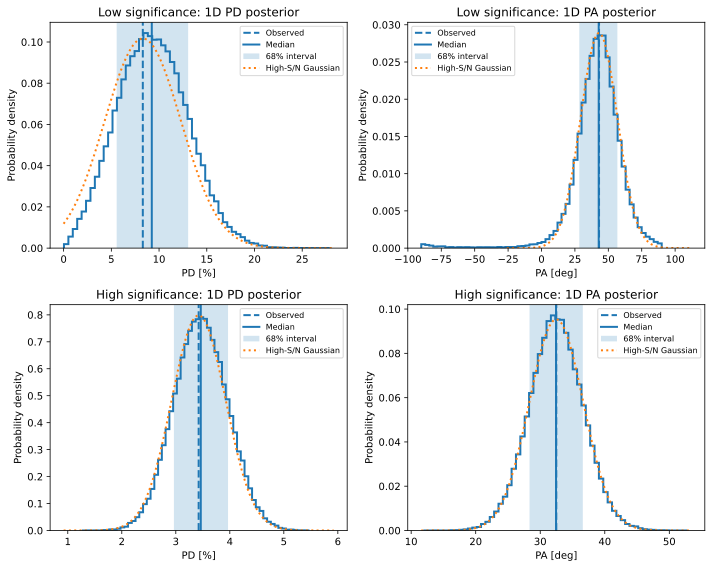

In [7]:
plt.close("all")

fig = plt.figure(figsize=(10, 8))

axes = np.empty((2, 2), dtype=object)

axes[0, 0] = fig.add_subplot(2, 2, 1)
axes[0, 1] = fig.add_subplot(2, 2, 2)

axes[1, 0] = fig.add_subplot(2, 2, 3)
axes[1, 1] = fig.add_subplot(2, 2, 4)


for row, case in enumerate(cases):

    q_obs = case["q_obs"]
    u_obs = case["u_obs"]
    cov = case["cov"]
    samples_qu = case["samples_qu"]

    pd_obs = case["pd_obs"]
    pa_obs = case["pa_obs"]
    pd_samples = case["pd_samples"]
    pa_samples = case["pa_samples"]

    sigma_q = case["sigma_q"]
    sigma_u = case["sigma_u"]

    # High-significance simplified approximation
    if np.isclose(sigma_q, sigma_u):
        sigma = sigma_q
        sigma_pd_simple = sigma
        sigma_pa_simple_rad = 0.5 * sigma / pd_obs
        sigma_pa_simple_deg = np.rad2deg(sigma_pa_simple_rad)
    else:
        sigma_pd_simple = None
        sigma_pa_simple_deg = None

    plot_pd_1d_panel(
        axes[row, 0],
        pd_samples,
        pd_obs,
        sigma_pd_simple=sigma_pd_simple,
        title=f"{case['label']}: 1D PD posterior",
    )

    plot_pa_1d_panel(
        axes[row, 1],
        pa_samples,
        pa_obs,
        sigma_pa_simple=sigma_pa_simple_deg,
        title=f"{case['label']}: 1D PA posterior",
    )

# axes[0, 0].set_xlim(-0.15, 0.15)
# axes[1, 0].set_xlim(-0.15, 0.15)

# axes[0, 0].set_ylim(-0.05, 0.20)
# axes[1, 0].set_ylim(-0.05, 0.20)


plt.tight_layout()
plt.show()

In [8]:
# ========================================================
# Print numerical summaries
# ========================================================

for case in cases:
    pd_samples = case["pd_samples"]
    pa_samples = case["pa_samples"]

    pd_med = np.median(pd_samples)
    pd_lo, pd_hi = np.percentile(pd_samples, [16, 84])

    pa_med = np.median(pa_samples)
    pa_lo, pa_hi = np.percentile(pa_samples, [16, 84])

    pd_obs = case["pd_obs"]
    pa_obs = case["pa_obs"]

    sigma = case["sigma_q"]

    # Simple high-S/N formula
    sigma_pd_simple = sigma
    sigma_pa_simple_deg = np.rad2deg(0.5 * sigma / pd_obs)

    print()
    print("=" * 70)
    print(case["label"])
    print("=" * 70)
    print(f"Acceptance fraction = {case['acceptance']:.3f}")
    print(f"Observed q = {case['q_obs']:.5f}")
    print(f"Observed u = {case['u_obs']:.5f}")
    print(f"Observed PD = {100 * pd_obs:.2f} %")
    print(f"Observed PA = {pa_obs:.2f} deg")
    print()
    print("MCMC transformed posterior:")
    print(f"PD = {100 * pd_med:.2f} +{100 * (pd_hi - pd_med):.2f} -{100 * (pd_med - pd_lo):.2f} %")
    print(f"PA = {pa_med:.2f} +{pa_hi - pa_med:.2f} -{pa_med - pa_lo:.2f} deg")
    print()
    print("Simplified high-significance approximation:")
    print(f"sigma_PD ≈ {100 * sigma_pd_simple:.2f} %")
    print(f"sigma_PA ≈ {sigma_pa_simple_deg:.2f} deg")


Low significance
Acceptance fraction = 0.714
Observed q = 0.00561
Observed u = 0.08279
Observed PD = 8.30 %
Observed PA = 43.06 deg

MCMC transformed posterior:
PD = 9.24 +3.81 -3.68 %
PA = 42.82 +13.96 -14.53 deg

Simplified high-significance approximation:
sigma_PD ≈ 4.00 %
sigma_PA ≈ 13.81 deg

High significance
Acceptance fraction = 0.714
Observed q = 0.01448
Observed u = 0.03102
Observed PD = 3.42 %
Observed PA = 32.48 deg

MCMC transformed posterior:
PD = 3.46 +0.50 -0.50 %
PA = 32.45 +4.15 -4.11 deg

Simplified high-significance approximation:
sigma_PD ≈ 0.50 %
sigma_PA ≈ 4.18 deg


## XSPEC spectral fitting with MCMC

In [9]:
import xspec
from astropy.io import fits
import os

---
## 1. Build a diagonal RMF and flat ARF

A **diagonal RMF** maps each true energy bin directly to the same PI channel — perfect energy resolution, no redistribution. This is the simplest valid response and lets us focus on the statistics rather than detector effects.

The **ARF** is set to 1000 cm² across all channels (flat effective area).

In [11]:

# ── Energy grid ─────────────────────────────────────────────────────────────
E_MIN = 0.3       # keV
E_MAX = 10.0      # keV
N_CH  = 300       # number of channels

# One continuous edge grid with N_CH + 1 edges
E_edges = np.linspace(E_MIN, E_MAX, N_CH + 1, dtype=np.float64)

# Lower and upper channel boundaries
ENERG_LO = E_edges[:-1].astype(np.float32)
ENERG_HI = E_edges[1:].astype(np.float32)

# Channel midpoints
E_MID = 0.5 * (ENERG_LO + ENERG_HI)

print(f"Energy grid: {N_CH} channels  {ENERG_LO[0]:.2f}–{ENERG_HI[-1]:.2f} keV")
print("Grid continuous?", np.allclose(ENERG_HI[:-1], ENERG_LO[1:]))

# ── Build ARF: flat 1000 cm^2 ───────────────────────────────────────────────
arf_file = "diag.arf"

arf_cols = [
    fits.Column(name="ENERG_LO", format="E", array=ENERG_LO, unit="keV"),
    fits.Column(name="ENERG_HI", format="E", array=ENERG_HI, unit="keV"),
    fits.Column(
        name="SPECRESP",
        format="E",
        array=np.full(N_CH, 1000.0, dtype=np.float32),
        unit="cm**2",
    ),
]

arf_hdu = fits.BinTableHDU.from_columns(arf_cols)
arf_hdu.header["EXTNAME"]  = "SPECRESP"
arf_hdu.header["TELESCOP"] = "SIMSAT"
arf_hdu.header["INSTRUME"] = "DIAG"
arf_hdu.header["FILTER"]   = "NONE"
arf_hdu.header["HDUCLASS"] = "OGIP"
arf_hdu.header["HDUCLAS1"] = "RESPONSE"
arf_hdu.header["HDUCLAS2"] = "SPECRESP"
arf_hdu.header["HDUVERS"]  = "1.1.0"

fits.HDUList([fits.PrimaryHDU(), arf_hdu]).writeto(
    arf_file,
    overwrite=True,
    checksum=True,
)

print(f"ARF written -> {arf_file}")

# ── Build diagonal RMF ──────────────────────────────────────────────────────
rmf_file = "diag.rmf"

# Use 1-based channel numbering for XSPEC-style PHA channels
CHANNEL = np.arange(1, N_CH + 1, dtype=np.int16)

# MATRIX extension:
# Each energy bin maps to exactly one detector channel with probability 1.
N_GRP  = np.ones(N_CH, dtype=np.int16)
F_CHAN = CHANNEL.reshape(N_CH, 1).astype(np.int16)
N_CHAN = np.ones((N_CH, 1), dtype=np.int16)
MATRIX = np.ones((N_CH, 1), dtype=np.float32)

matrix_cols = [
    fits.Column(name="ENERG_LO", format="E",  array=ENERG_LO, unit="keV"),
    fits.Column(name="ENERG_HI", format="E",  array=ENERG_HI, unit="keV"),
    fits.Column(name="N_GRP",    format="I",  array=N_GRP),
    fits.Column(name="F_CHAN",   format="1I", array=F_CHAN),
    fits.Column(name="N_CHAN",   format="1I", array=N_CHAN),
    fits.Column(name="MATRIX",   format="1E", array=MATRIX),
]

matrix_hdu = fits.BinTableHDU.from_columns(matrix_cols)
matrix_hdu.header["EXTNAME"]  = "MATRIX"
matrix_hdu.header["TELESCOP"] = "SIMSAT"
matrix_hdu.header["INSTRUME"] = "DIAG"
matrix_hdu.header["FILTER"]   = "NONE"
matrix_hdu.header["HDUCLASS"] = "OGIP"
matrix_hdu.header["HDUCLAS1"] = "RESPONSE"
matrix_hdu.header["HDUCLAS2"] = "RSP_MATRIX"
matrix_hdu.header["HDUCLAS3"] = "REDIST"
matrix_hdu.header["HDUVERS"]  = "1.3.0"
matrix_hdu.header["RMFVERSN"] = "1992a"
matrix_hdu.header["CHANTYPE"] = "PI"
matrix_hdu.header["DETCHANS"] = N_CH
matrix_hdu.header["NUMGRP"]   = N_CH
matrix_hdu.header["NUMELT"]   = N_CH
matrix_hdu.header["LO_THRES"] = 0.0

# Tell FITS/XSPEC that F_CHAN and N_CHAN are 1-based channel quantities
matrix_hdu.header["TLMIN4"] = 1
matrix_hdu.header["TLMAX4"] = N_CH
matrix_hdu.header["TLMIN5"] = 1
matrix_hdu.header["TLMAX5"] = N_CH

# EBOUNDS extension: maps detector channel index to energy range
ebounds_cols = [
    fits.Column(name="CHANNEL", format="I", array=CHANNEL),
    fits.Column(name="E_MIN",   format="E", array=ENERG_LO, unit="keV"),
    fits.Column(name="E_MAX",   format="E", array=ENERG_HI, unit="keV"),
]

ebounds_hdu = fits.BinTableHDU.from_columns(ebounds_cols)
ebounds_hdu.header["EXTNAME"]  = "EBOUNDS"
ebounds_hdu.header["TELESCOP"] = "SIMSAT"
ebounds_hdu.header["INSTRUME"] = "DIAG"
ebounds_hdu.header["FILTER"]   = "NONE"
ebounds_hdu.header["HDUCLASS"] = "OGIP"
ebounds_hdu.header["HDUCLAS1"] = "RESPONSE"
ebounds_hdu.header["HDUCLAS2"] = "EBOUNDS"
ebounds_hdu.header["HDUVERS"]  = "1.2.0"
ebounds_hdu.header["CHANTYPE"] = "PI"
ebounds_hdu.header["DETCHANS"] = N_CH
ebounds_hdu.header["TLMIN1"]   = 1
ebounds_hdu.header["TLMAX1"]   = N_CH

# Standard RMF order: PRIMARY, MATRIX, EBOUNDS
fits.HDUList([fits.PrimaryHDU(), matrix_hdu, ebounds_hdu]).writeto(
    rmf_file,
    overwrite=True,
    checksum=True,
)

print(f"RMF written -> {rmf_file}  diagonal, {N_CH} x {N_CH}")

Energy grid: 300 channels  0.30–10.00 keV
Grid continuous? True
ARF written -> diag.arf
RMF written -> diag.rmf  diagonal, 300 x 300


---
## 2. Simulate a fake spectrum with `fakeit`

True model: **tbabs × powerlaw**
- nH = 0.05*10^22 cm⁻²
- Γ  = 1.8
- norm = 1*10^-3 photons/cm²/s/keV at 1 keV

Exposure: 50 ks (~ 10 000) net counts (regime where $\chi^2$ is valid).

In [12]:
# ── True parameter values (we will recover these with MCMC) ──────────────────
TRUE_NH   = 0.05    # 10^22 cm^-2
TRUE_GAMA = 1.80
TRUE_NORM = 1.0e-2
EXPOSURE  = 50000.0   # seconds
FAKE_FILE = 'sim_spectrum.fak'

if os.path.exists(FAKE_FILE):
    os.remove(FAKE_FILE)

# ── Set up XSPEC ─────────────────────────────────────────────────────────────
xspec.AllData.clear()
xspec.AllModels.clear()

# Define the model
model = xspec.Model('tbabs*powerlaw')

model.TBabs.nH.values   = TRUE_NH
model.powerlaw.PhoIndex.values = TRUE_GAMA
model.powerlaw.norm.values     = TRUE_NORM

print(">>> Parameters reset")
xspec.AllModels.setEnergies("reset")


#fakeit settings: use our diagonal responses, no background
fs = xspec.FakeitSettings(
    response   = rmf_file,
    arf        = arf_file,
    exposure   = EXPOSURE,
    fileName = FAKE_FILE
)

xspec.AllData.fakeit(1, fs)

# # Ignore low-S/N edges; notice 0.5–8.0 keV
xspec.AllData(1).ignore('**-0.5 8.0-**')

# # Report
# net_counts = xspec.AllData(1).rate[2] * xspec.AllData(1).exposure
# print(f'Fake spectrum saved: {FAKE_FILE}')
# print(f'Net counts in 0.5–8 keV: {net_counts:.0f}')
# print(f'True model: tbabs(nH={TRUE_NH}) × powerlaw(Γ={TRUE_GAMA}, norm={TRUE_NORM:.1e})')

tbvabs Version 2.3
Cosmic absorption with grains and H2, modified from
Wilms, Allen, & McCray, 2000, ApJ 542, 914-924
Questions: Joern Wilms
joern.wilms@sternwarte.uni-erlangen.de
joern.wilms@fau.de

http://pulsar.sternwarte.uni-erlangen.de/wilms/research/tbabs/

PLEASE NOTICE:
To get the model described by the above paper
you will also have to set the abundances:
   abund wilm

>>> Parameters reset
Note that this routine ignores the current cross section setting
as it always HAS to use the Verner cross sections as a baseline.

Model TBabs<1>*powerlaw<2> Source No.: 1   Active/Off
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    1.00000      +/-  0.0          
   2    2   powerlaw   PhoIndex            1.00000      +/-  0.0          
   3    2   powerlaw   norm                1.00000      +/-  0.0          
________________________________________________________________________


All model energies will be taken from non-extended r

***Warning: Fit is not current.


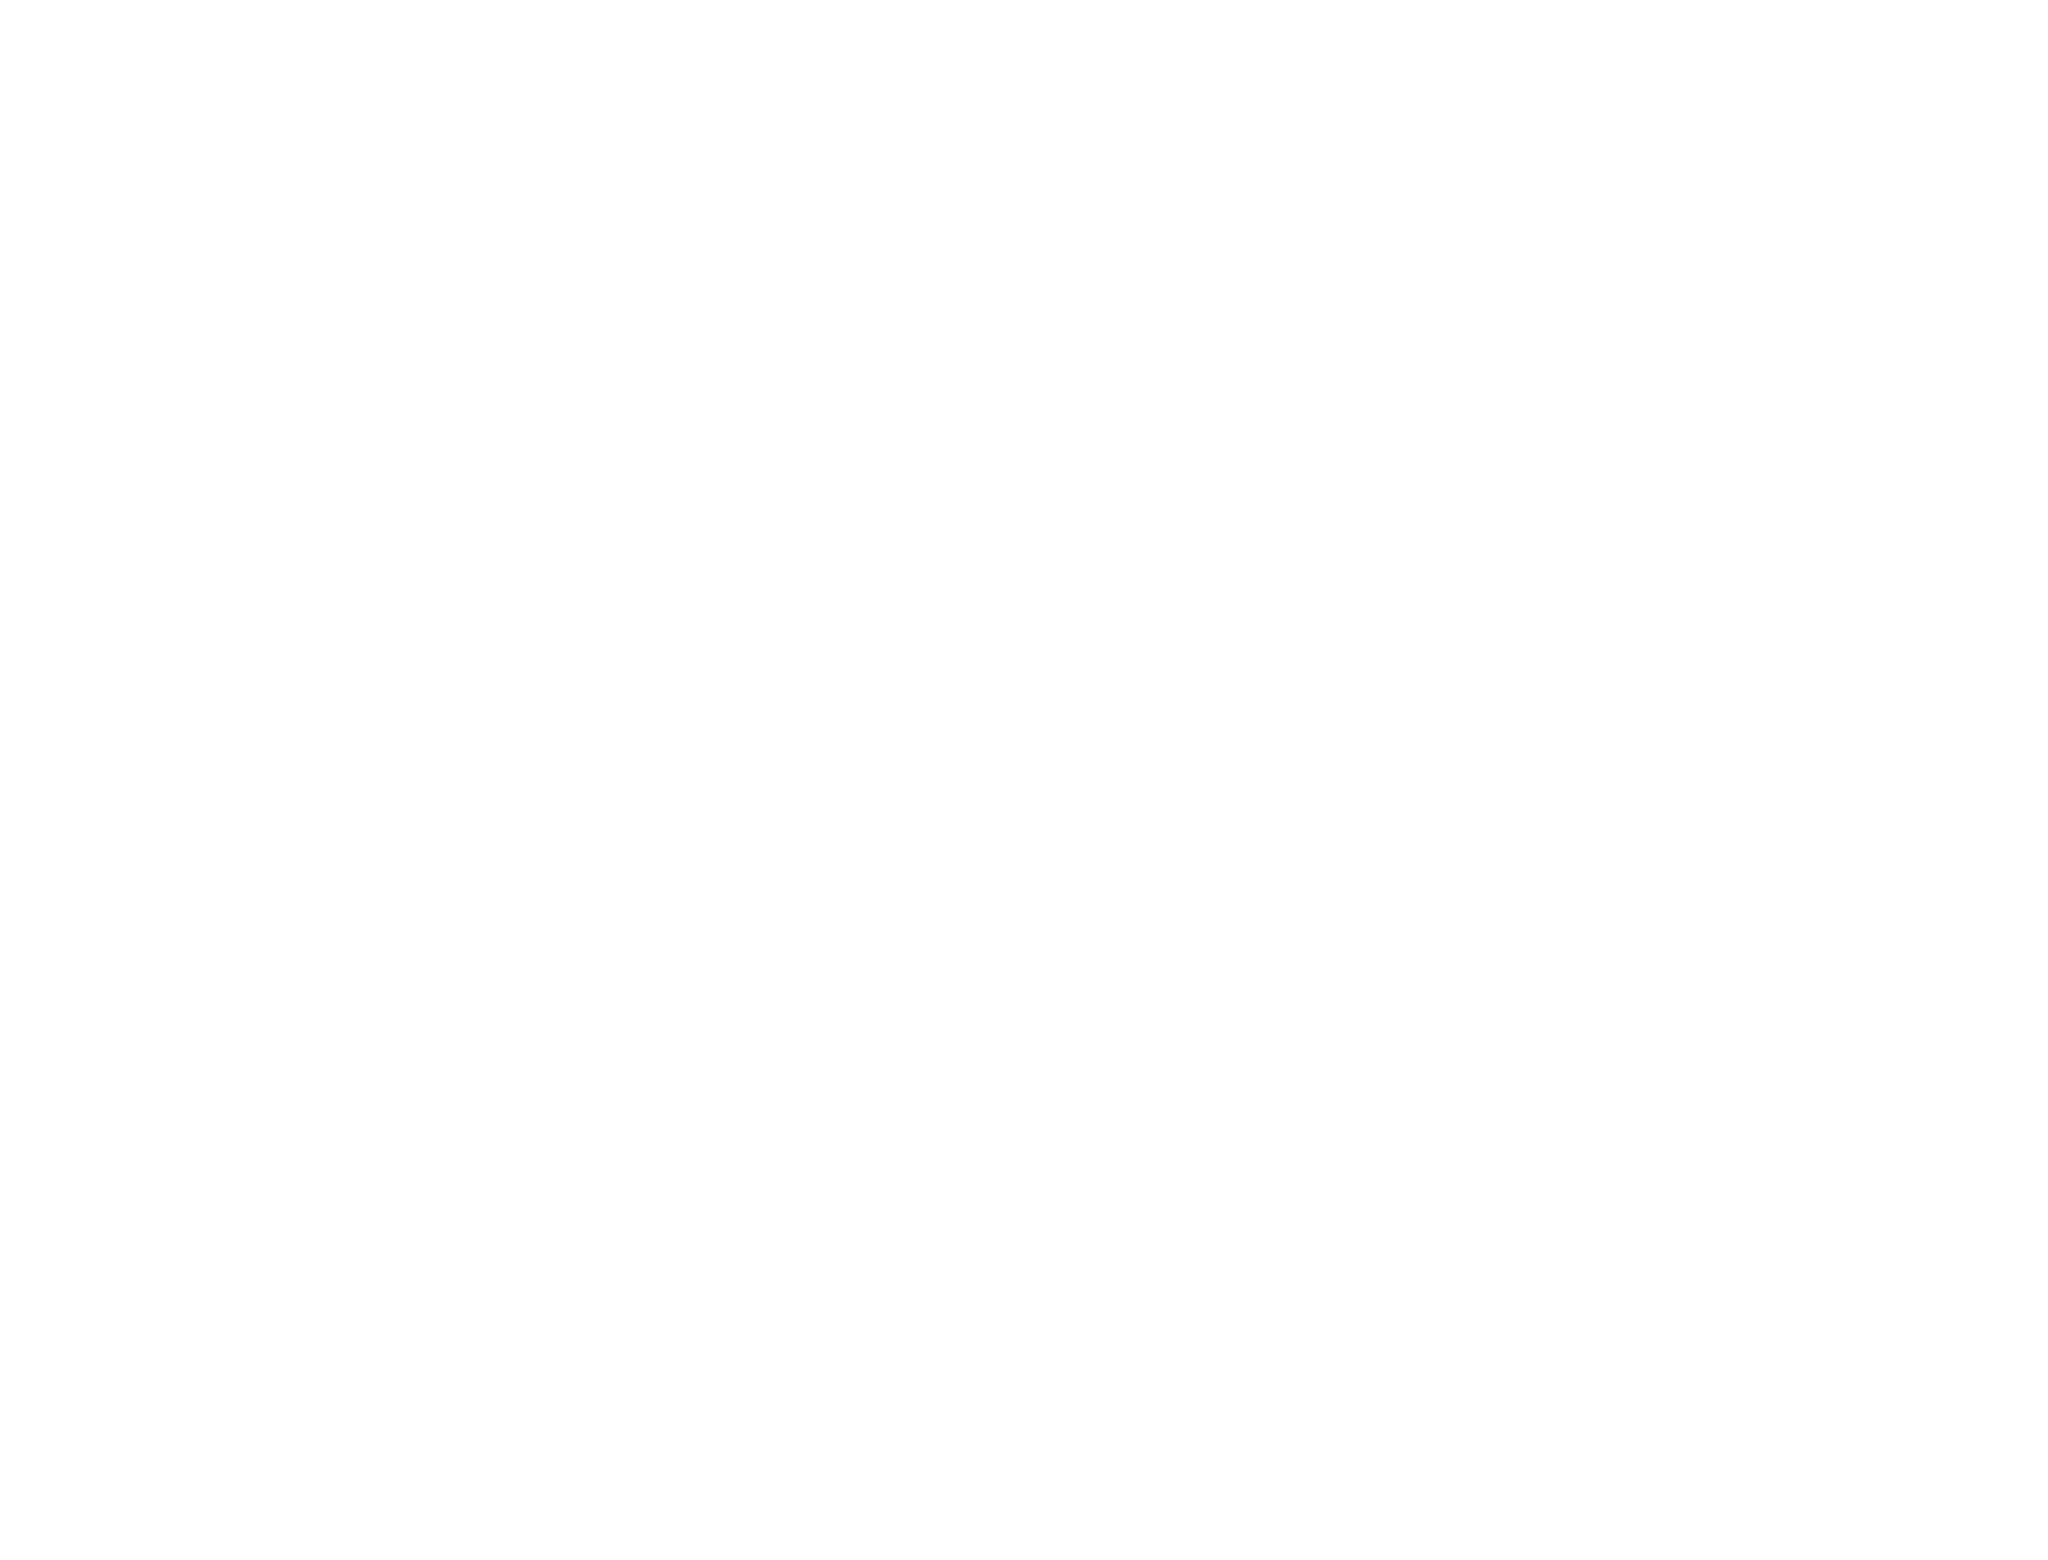

In [13]:
xspec.Plot.device = "/svg"
xspec.Plot.xAxis = "keV"
xspec.Plot("data")

In [14]:
xspec.Fit.statMethod = 'cstat'
xspec.Fit.nIterations = 1000
xspec.Fit.perform()

# ── Print fit results ────────────────────────────────────────────────────────
xspec.Fit.show()

Default fit statistic is set to: C-Statistic
   This will apply to all current and newly loaded spectra.

Fit statistic  : C-Statistic                  245.75     using 231 bins.

Test statistic : Chi-Squared                  247.32     using 231 bins.
 Null hypothesis probability of 1.81e-01 with 228 degrees of freedom
 Current data and model not fit yet.
                                   Parameters
C-Statistic  |beta|/N    Lvl          1:nH    2:PhoIndex        3:norm
243.955      637.135      -3     0.0498020       1.80053    0.00998458
243.955      2.59683      -4     0.0498003       1.80052    0.00998452
 Variances and Principal Axes
                 1        2        3  
 1.2380E-10| -0.0259  -0.0034   0.9997  
 1.6210E-07|  0.9753  -0.2194   0.0245  
 9.0670E-06|  0.2193   0.9756   0.0090  
----------------------------------------

  Covariance Matrix
        1           2           3   
   5.901e-07   1.905e-06   2.181e-08
   1.905e-06   8.638e-06   7.891e-08
   2.181e-08   7.

In [15]:
#xspec.Fit.show()

---
## 6. Run the MCMC chain

### What XSPEC does internally
1. Starts at the current best-fit (θ₀)
2. At each step: proposes θ* from a Gaussian centred on θ (scaled by the fit covariance)
3. Computes Δ(−χ²/2) = ln π(θ*) − ln π(θ)
4. Accepts with probability min(1, exp(Δ)) — Metropolis–Hastings
5. Appends the current state (accepted or current) to the chain

### Key settings
| Parameter | Meaning | Typical value |
|---|---|---|
| `length` | Total steps per walker | 20 000–100 000 |
| `burn` | Steps discarded as burn-in | 20–50% of length |
| `walkers` | Parallel chains (Goodman–Weare) | 2×N_params minimum |
| `proposal` | Proposal distribution | gaussian (default) |
| `scale` | Proposal width multiplier | tune for ~25% acceptance |

In [16]:
CHAIN_FILE = 'mcmc_chain.fits'
N_STEPS    = 30000
N_BURN     = 5000
N_WALKERS  = 10  

# Remove old chain file if present
if os.path.exists(CHAIN_FILE):
    os.remove(CHAIN_FILE)

# ── Configure and run ────────────────────────────────────────────────────────
#xspec.Xset.chatter = 5   # show progress

chain = xspec.Chain(
    fileName  = CHAIN_FILE,
    runLength = N_STEPS,
    walkers   = N_WALKERS,
    burn      = N_BURN,
    #proposal  = 'gaussian'
)

print(f'\nChain complete → {CHAIN_FILE}')
print(f'Total post-burn samples: {(N_STEPS - N_BURN) * N_WALKERS}')
xspec.Xset.chatter = 0

  New chain mcmc_chain.fits is now loaded.

Chain complete → mcmc_chain.fits
Total post-burn samples: 250000


In [17]:
with fits.open(CHAIN_FILE) as hdul:
    hdul.info()
    chain_data = hdul[1].data
    colnames   = chain_data.names

print('\nChain columns:', colnames)

# Extract parameter columns (skip FIT_STATISTIC)
param_cols = [c for c in colnames if 'FIT' not in c.upper()]
print('Parameter columns:', param_cols)

# Build array: shape (n_samples, n_params)
samples = np.column_stack([chain_data[c] for c in param_cols])
n_samples, n_params = samples.shape
stat    = chain_data['FIT_STATISTIC']

print(f'\nChain shape: {samples.shape}  (samples × parameters)')

Filename: mcmc_chain.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1  CHAIN         1 BinTableHDU     48   30000R x 4C   [D, D, D, D]   

Chain columns: ['nH__1', 'PhoIndex__2', 'norm__3', 'FIT_STATISTIC']
Parameter columns: ['nH__1', 'PhoIndex__2', 'norm__3']

Chain shape: (30000, 3)  (samples × parameters)


In [22]:
xspec.AllData.clear()
xspec.AllModels.clear()

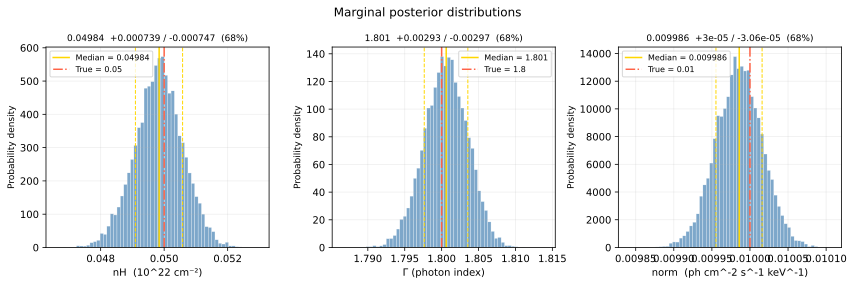

In [18]:
true_vals = [TRUE_NH, TRUE_GAMA, TRUE_NORM]
param_labels = ['nH  (10^22 cm⁻²)', 'Γ (photon index)', 'norm  (ph cm^-2 s^-1 keV^-1)']

fig, axes = plt.subplots(1, n_params, figsize=(4 * n_params, 4))

for i, ax in enumerate(axes):
    ax.hist(samples[:, i], bins=60, color='steelblue', alpha=0.7,
            density=True, edgecolor='white', linewidth=0.3)

    lo, med, hi = np.percentile(samples[:, i], [16, 50, 84])
    ax.axvline(med,        color='gold',   lw=1.5, label=f'Median = {med:.4g}')
    ax.axvline(lo,         color='gold',   lw=1.0, ls='--')
    ax.axvline(hi,         color='gold',   lw=1.0, ls='--')
    ax.axvline(true_vals[i], color='tomato', lw=1.5, ls='-.',
               label=f'True = {true_vals[i]}')

    ax.set_xlabel(param_labels[i], fontsize=10)
    ax.set_ylabel('Probability density', fontsize=9)
    ax.set_title(f'{med:.4g}  +{hi-med:.3g} / -{med-lo:.3g}  (68%)', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

fig.suptitle('Marginal posterior distributions', fontsize=12)
fig.tight_layout()
plt.show()

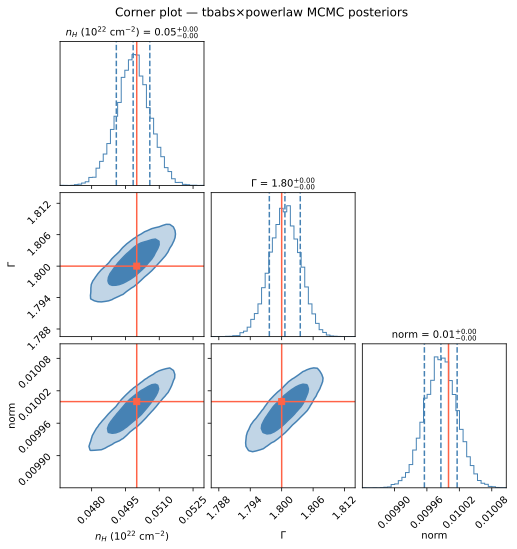

In [19]:
try:
    import corner
except ImportError:
    print('Install corner: pip install corner')
    raise

labels_corner = [r'$n_H$ ($10^{22}$ cm$^{-2}$)',
                 r'$\Gamma$',
                 r'norm']

fig = corner.corner(
    samples,
    labels       = labels_corner,
    truths       = true_vals,
    truth_color  = 'tomato',
    quantiles    = [0.16, 0.50, 0.84],
    show_titles  = True,
    title_kwargs = {'fontsize': 10},
    bins         = 40,
    smooth       = 1.0,
    plot_datapoints = False,
    fill_contours   = True,
    levels       = [0.68, 0.95],
    color        = 'steelblue'
)
fig.suptitle('Corner plot — tbabs×powerlaw MCMC posteriors', y=1.01, fontsize=12)
plt.show()

In [20]:
def make_corner_from_sample(samples, labels, outfile):
    """
    
    Parameters:
    -----------
    samples: array
        [nsamples, ndim]
    labels: list, str
        [ndim]
    outfile: str
        The output name for the figure.
    """
    
    import corner
    
    lines = []
    
    for i in range(len(labels)):
        lines.append(get_interval(samples[:,i]))
    
    fig = corner.corner(samples,labels=labels, levels=(0.68,0.95,0.99))
    
    num = len(labels)
    
    axes = np.array(fig.axes).reshape((num,num))
    for i in range(num):
        axes[i,i].axvline(lines[i][0],color = 'red')
        axes[i,i].axvline(lines[i][1],color = 'red', ls='--')
        axes[i,i].axvline(lines[i][2],color = 'red', ls='--')
    
    fig.savefig(outfile)
    
    return True

def get_interval(x, level=0.9, center=None):
    """
    Calculate confidence interval from MCMC samples.
    
    Parameters:
    -----------
    x: 1D array
        The samples for one parameter.
    level: float
        The confidence level. Must be between 0 and 1.
    center: optional
        The mid point (best-fit value). If not specified, the
        median will be used.
    
    Return:
    -------
    center, lower bound, higher bound
    
    Reference:
    ----------
    [1] http://www-personal.umd.umich.edu/~wiclarks/AstroLab/HOWTOs/NotebookStuff/MonteCarloHOWTO.html
    """
    
    if center is None:
        message = ('Center value is not given, '
                   'will use the mid!')
        print(message)
        mid = np.percentile(x, 50.0)
    else:
        mid = center
        
    num_sample = len(x)
    #mid_index = np.where(x==mid)[0][0]
    
    ghigh = np.where(x>=mid)[0]
    glow = np.where(x<mid)[0]
    
    vSortlo = np.sort(x[glow])
    vSorthi = np.sort(x[ghigh])
    
    # How to handle a non-gaussian distribution?
    
    if float(np.size(vSortlo))/float(num_sample)<level/2.0:
        NormLo = vSortlo[0]
        NormHi = np.percentile(x, level*100.0)
        #print('lower limit touched: {0}, {1}'.format(np.size(vSortlo), num_sample))
    elif float(np.size(vSorthi))/float(num_sample)<level/2.0:
        NormLo = np.percentile(x, (1.0-level)*100.0)
        NormHi = vSorthi[-1]
        #print('higer limit touched {0}, {1}'.format(np.size(vSorthi), num_sample))
    else:
        NormLo = vSortlo[int(np.size(vSortlo)-num_sample*level/2.0)]
        NormHi = vSorthi[int(num_sample*level/2.0)]
    
    return mid, NormLo, NormHi

def make_corner_from_chain(chain_fits, outfile, burn=0):
    """
    Make the corner plot with MCMC chain file from XSPEC.
    All parameters
    """
    
    import corner
    
    samples = []
    labels = []
    lines = []
    
    hdul = fits.open(chain_fits)
    
    chain_sample = hdul[1].data
    namelist = hdul[1].columns.names
    
    for i in range(len(namelist)-1):
        samples.append(chain_sample[namelist[i]][burn:-1])
        labels.append(namelist[i].split('__')[0])
        lines.append(get_interval(chain_sample[namelist[i]][burn:-1]))
    
    samples = np.array(samples).T
    
    fig = corner.corner(samples,labels=labels, levels=(0.68,0.95,0.99))
    
    num = len(labels)
    
    axes = np.array(fig.axes).reshape((num,num))
    for i in range(num):
        axes[i,i].axvline(lines[i][0],color = 'red')
        axes[i,i].axvline(lines[i][1],color = 'red', ls='--')
        axes[i,i].axvline(lines[i][2],color = 'red', ls='--')
    
    fig.savefig(outfile)
    
    hdul.close()
    
    return True

In [23]:
# true_vals = [TRUE_NH, TRUE_GAMA, TRUE_NORM]

# make_corner_from_chain("mcmc_chain.fits","temp.pdf",0)